Mini-project: adoptable dog predictor - gradient boosting edition

For continuity, we will use the same dataset as the decision tree and random forest notebooks.

Target:
- adopted_fast

Features:
- age
- size
- energy_level
- good_with_kids
- trained
- cute_score

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

m = 200

age = np.random.randint(0, 15, size=m)
size = np.random.choice([0,1,2], size=m)
energy_level = np.random.choice([1,2,3,4,5], size=m)
good_with_kids = np.random.choice([0,1], size=m)
trained = np.random.choice([0,1], size=m)
cute_score = np.random.randint(1, 11, size=m)

X = pd.DataFrame({
    "age": age,
    "size": size,
    "energy_level": energy_level,
    "good_with_kids": good_with_kids,
    "trained": trained,
    "cute_score": cute_score
})

X.head()

,age,size,energy_level,good_with_kids,trained,cute_score
0,6,0,4,0,1,10
1,3,2,1,1,0,2
2,12,2,4,1,0,1
3,14,0,5,0,1,10
4,10,2,5,0,1,9


In [2]:
score = (
    (age < 5)*2 +
    good_with_kids*2 +
    trained*2 +
    (energy_level >= 4)*1 +
    (cute_score >= 7)*1
)

y = (score >= 4).astype(int)

# add randomness
np.random.seed(42)
noise = np.random.rand(m) < 0.1
y = np.where(noise, 1 - y, y)

data = X.copy()
data["adopted_fast"] = y
data.head()

,age,size,energy_level,good_with_kids,trained,cute_score,adopted_fast
0,6,0,4,0,1,10,1
1,3,2,1,1,0,2,1
2,12,2,4,1,0,1,0
3,14,0,5,0,1,10,1
4,10,2,5,0,1,9,1


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

We will train and compare 4 models:
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [46]:
from sklearn.metrics import accuracy_score

train_acc = {}
val_acc = {}

for model in models:
    models[model].fit(X_train, y_train)

    train_acc[model] = accuracy_score(y_train, models[model].predict(X_train))
    val_acc[model] = accuracy_score(y_val, models[model].predict(X_val))

In [47]:
for key in train_acc:
    print(key, ': accuracy on training set:', train_acc[key],' , validation set:', val_acc[key])

Tree : accuracy on training set: 0.9428571428571428  , validation set: 0.7166666666666667
Random Forest : accuracy on training set: 1.0  , validation set: 0.8333333333333334
AdaBoost : accuracy on training set: 0.8571428571428571  , validation set: 0.7333333333333333
Gradient Boosting : accuracy on training set: 0.9785714285714285  , validation set: 0.8


- Decision tree: overfitting since our results show low bias but high variance

- Random forest: extremely high training accuracy, and validation accuracy is the highest out of all models -> random forests reduce variance by averaging many trees, so that's expected

- AdaBoost: quite interesting results as AdaBoost performs worse here and seems to be underfitting. 

- Gradient boosting: low bias and low variance

For AdaBoost and Gradient Boosting, we can plot the learing curves:

In [48]:
n_estimators = [1, 5, 10, 20, 50, 100, 200]
rf_train, rf_val = [], []
ada_train, ada_val = [], []
gb_train, gb_val = [], []

for n in n_estimators:
    # for Random Forest
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    rf_train.append(accuracy_score(y_train, model.predict(X_train)))
    rf_val.append(accuracy_score(y_val, model.predict(X_val)))

    # for AdaBoost
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    ada_train.append(accuracy_score(y_train, model.predict(X_train)))
    ada_val.append(accuracy_score(y_val, model.predict(X_val)))

    # for Gradient Boosting
    model = GradientBoostingClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    gb_train.append(accuracy_score(y_train, model.predict(X_train)))
    gb_val.append(accuracy_score(y_val, model.predict(X_val)))

Text(0.5, 1.0, 'Validation')

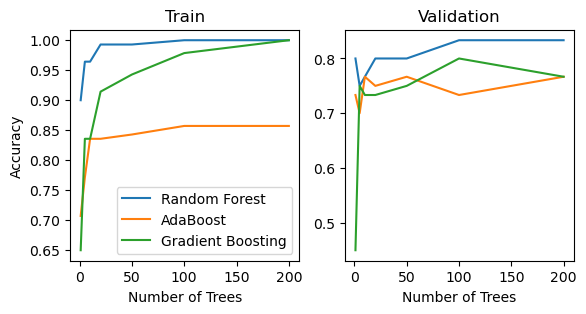

In [66]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1,2,figsize=(6.5,3))
ax[0].plot(n_estimators, rf_train, label="Random Forest")
ax[0].plot(n_estimators, ada_train, label="AdaBoost")
ax[0].plot(n_estimators, gb_train, label="Gradient Boosting")

ax[0].set_xlabel("Number of Trees")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].set_title("Train")

ax[1].plot(n_estimators, rf_val, label="Random Forest")
ax[1].plot(n_estimators, ada_val, label="AdaBoost")
ax[1].plot(n_estimators, gb_val, label="Gradient Boosting")

ax[1].set_xlabel("Number of Trees")
ax[1].set_title("Validation")

- Random forest: rapid improvement then plateau as expected -> variance reduction happens quickly

- AdaBoost: both accuracies stay limited -> stumps being weak learners may explain that behavior on this specific dataset

- Gradient boosting: training accuracy increases steadily, while validation accuracy peaks then stabilizes, which is typical boosting behavior -> trees sequentially correct errors

A single decision tree tends to overfit due to its high variance. Random Forest improves generalization by averaging many independent trees trained on bootstrapped samples, which significantly reduces variance. Boosting methods build trees sequentially to correct previous errors. In this experiment, Gradient Boosting achieved strong performance by progressively reducing bias, while AdaBoost slightly underfit due to its use of weaker base learners.